In [ ]:

# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime
from tudatpy.astro import element_conversion
# For the minor planets 
from tudatpy.data import horizons


# Step 1: Setup Conditions/ Basic Conditions

# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
# Start dat = 25th of April 2004 (arbitrary choice)
# Tudat works in J2000, so use seconds
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch() - 12 * 3600
simulation_end_epoch   = simulation_start_epoch + 60 * constants.JULIAN_YEAR


# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create = [
    "Sun",
    # "Earth",
    "Mercury",
    # "Venus",
    # "Mars",
    # "Jupiter",
    # "Saturn",
    # "Uranus",
    # "Neptune"
]

# The 21 smaller bodies do not exist inside of SPICE and therefore their mu has to be manually added
# Create a dictionary to store the names, ID numbers and mu (GM in km3/s2) of the asteroids 

# Will check later if I need to add e.g. radius, radiation or time of orbit around the Sun etc.

smaller_bodies = {
    # "Ceres": [1, 62.10], 
    # "Pallas": [2, 13.73],
    # "Juno": [3, 1.61],
    # "Vesta": [4, 17.38],
    # "Hebe": [6, 0.89],
    # "Iris": [7, 0.73],
    # "Flora": [8, 0.27],
    # "Metis": [9, 0.44],
    # "Hygiea": [10, 5.97],
    # "Irene": [14, 0.25],
    # "Eunomia": [15, 1.88],
    # "Psyche": [16, 1.65],
    # "Fortuna": [19, 0.42],
    # "Thalia": [23, 0.15],
    # "Amphitrite": [29, 0.98],
    # "Daphne": [41, 0.56],
    # "Europa": [52, 1.48],
    # "Bamberga": [324, 0.71],
    # "Davida": [511, 1.14],
    # "Herculina": [532, 0.66],
    # "Interamnia": [704, 2.65]
}

# Extract only the names 
# This is so that the list of all bodies can be created
smaller_bodies_list = list(smaller_bodies.keys())


# Manually add 1998 TU3
asteroid_name = "1998-TU3"


# Combine all bodies into one large list
bodies_to_create = larger_bodies_to_create + smaller_bodies_list + [asteroid_name]
bodies_to_propagate = asteroid_name     # I only propagate TU3, I pull the other values from pre-existing ephemeris



# ----------------------------
# Create bodies in simulation.

# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'Sun', 
    base_frame_orientation = 'ECLIPJ2000')


# To avoid the issue of calling for coordinates that don't exist in the ephermeris
# Add a buffer time

buffer_time = 5 * constants.JULIAN_DAY

# A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon

for i, (name, data) in enumerate(smaller_bodies.items(), start=1):

    # Extract asteroid properties
    ast_id = data[0]
    ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units)

    try:

        # --------------------------------------------
        # Extracting the ephemeris from JPL Horizons (not SPICE)

        # ephemeris_settings_ast = environment_setup.ephemeris.jpl_horizons(
        #     horizons_query = str(ast_id),
        #     horizons_location = "@0",       # This sets the center at the SSB (an exact command)
        #     frame_origin = "SSB",
        #     frame_orientation = "ECLIPJ2000",    # Debate between ECLIPJ2000 and J2000
        #     epoch_start = simulation_start_epoch - buffer_time,
        #     epoch_end = simulation_end_epoch + buffer_time,
        #     epoch_step = "1d",              # 1 day step
        #     extended_query = True           # Helps Horizon resolve asteroids' IDs more robustly
        # )


        # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
        DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
            frame_origin = 'SSB', 
            frame_orientation = 'ECLIPJ2000', 
            body_name_to_use = name)


        # Create empty slots, then insert the asteroids
        body_settings.add_empty_settings(name)
        # Assign ephemeris
        body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast

        # Assign gravity field (central function that manually adds the mu)
        body_settings.get(name).gravity_field_settings = (
            environment_setup.gravity_field.central(ast_mu)
        )

        print(f" {i}. Successfully configured {name} (ID: {ast_id})")

    except Exception as e:

        print(f"Could not fetch data for {name}: {e}")


# Manually add empty settings for TU3
body_settings.add_empty_settings(asteroid_name)

# Thus, the environment becomes:
body_system = environment_setup.create_system_of_bodies(body_settings)

# ===========================================
# Step 3: Create the Propagation Setup

bodies_to_propagate = ["1998-TU3"]

central_bodies = ["SSB"]
# ===========================================

# Step 4: Define the accelerations acting on TU3 (for now)

# The planets
accelerations_planets = {
    "Sun": [
        propagation_setup.acceleration.point_mass_gravity(),
        # propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # propagation_setup.acceleration.yarkovsky(-2.65*10**(-14)),                      # The Yarkovsky parameter (Supposed to be added to the asteroid in the code?)
        # propagation_setup.acceleration.spherical_harmonic()                           # The solar quadrupole moment

    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    # "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    # "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    # "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    # "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    # "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    # "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    # "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# The asteroids

accelerations_asteroids = {
    
    asteroid_name: [
        propagation_setup.acceleration.point_mass_gravity()
    ]
    for asteroid_name in smaller_bodies_list
}

# Merge dictionaries
accelerations_merged = (
    accelerations_planets |
    accelerations_asteroids
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict = {
    "1998-TU3": accelerations_merged
}



# Step 5: Define the Initial States of Each Body
# This is where we mix SPICE data (for the planets) with Keplerian data (the asteroid)

sun_gravitational_parameter = body_system.get("Sun").gravitational_parameter

# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)

# Cartesian state vector
cartesian_elements = np.array([
    [4.543863572576185E+07 * 1e3],   # X  [m]
    [-9.673019712424231E+07 * 1e3],  # Y  [m]
    [-2.313075952057116E+06 * 1e3],  # Z  [m]
    [3.661410298575712E+01 * 1e3],   # VX [m/s]
    [-1.757686929389374E+00 * 1e3],  # VY [m/s]
    [-3.350242409196601E+00 * 1e3]   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter
    )

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])

    # ---------------------------------
    # New initial condition

initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter = sun_gravitational_parameter,
    semi_major_axis = test_initial_TU3_array[0],                 #meters
    eccentricity = test_initial_TU3_array[1],                    #unitless
    inclination = test_initial_TU3_array[2],                     # cartesian_to_keplerian returns angles in radians
    argument_of_periapsis = test_initial_TU3_array[3],
    longitude_of_ascending_node = test_initial_TU3_array[4],
    true_anomaly = test_initial_TU3_array[5],                
)



system_initial_state = initial_state_TU3


# Step 6: Create the conditions for propagation:

# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch) # 15 years after the epoch begins

# Create numerical integrator settings
fixed_step_size = 3600.0    # each hour
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, 
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78     # Range-Kutta 78 instead of 4 (more precise as I do 1 hour steps for many years)
)


# Create the acceleration model
acceleration_models = (
    propagation_setup.create_acceleration_models(
        body_system,
        acceleration_dict,
        bodies_to_propagate,
        central_bodies
    )
)



# Propagating TU3 with the created system
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)



# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    body_system, propagator_settings
)

# Extract the resulting state history and convert it to an ndarray
states_TU3 = dynamics_simulator.propagation_results.state_history
states_array_TU3 = result2array(states_TU3)



# Extract the times 
times = states_array_TU3[:,0]

print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: \n{
    states_TU3[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 is [km]: \n{
    states_TU3[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_end_epoch][3:] / 1E3}
    """
)

# print(asteroid_ephemerides["Ceres"][0])
# print(asteroid_ephemerides["Ceres"][100])



# Extract the 21 asteroids:
# Also to check what the heck the asteroids' coordinates look like:

asteroid_ephemerides = {}

for asteroid_name in smaller_bodies_list:

    asteroid_states = np.array([

        body_system.get(asteroid_name)
        .ephemeris
        .cartesian_state(time)

        for time in times

    ])

    asteroid_ephemerides[asteroid_name] = asteroid_states

    # The planets are extracted similarly when plotting the Solar System



Keplerian Elements:
[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
117640977822.613
0.09419482774380611

Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 1893456000.0 seconds the position vector of TU3 is [km]: 
[ 77781573.32562196 -94286492.8566798   -5361117.24612315]
And the velocity vector of TU3 is [km/s]: 
[31.49779372  6.32528064 -3.03630955]
    


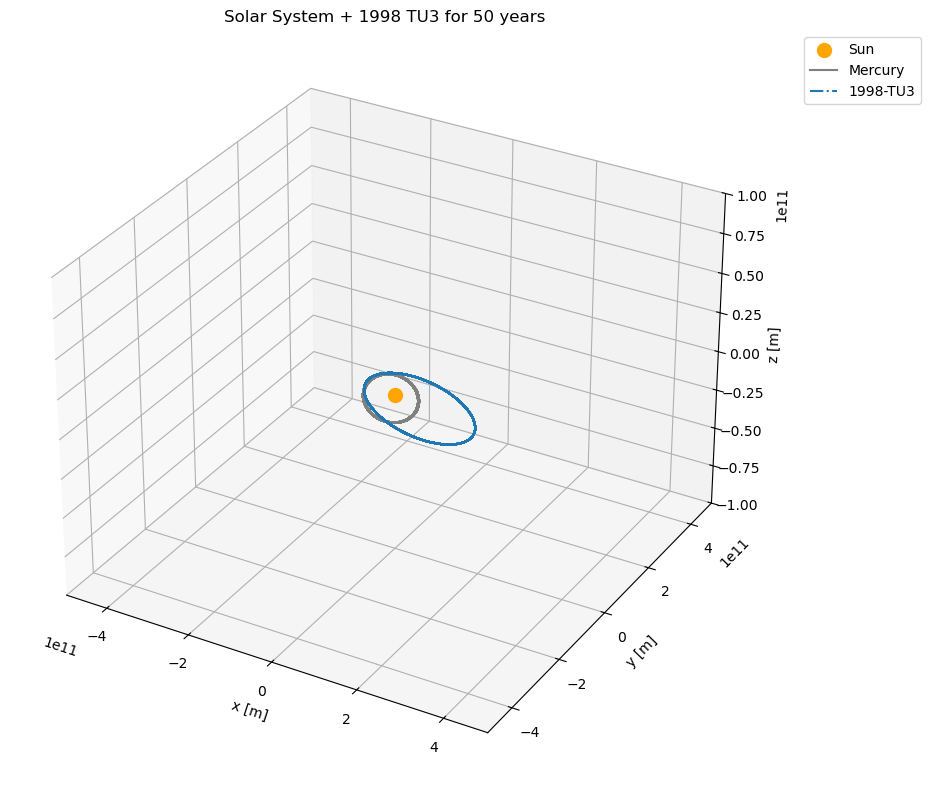

In [2]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Solar System + 1998 TU3 for 50 years')

ax.scatter(0,0,0,s=100,label="Sun", color='orange')

# Define colors or a colormap for variety
#planet_colours = ['silver', 'gold', 'teal', 'tab:red', 'darkorange', 'wheat', 'lightblue', 'royalblue']
planets_names = ["Mercury"]
# planets_names = ["Mercury","Venus","Earth","Mars","Jupiter","Saturn","Uranus","Neptune"]

# Loop through the planets you created in Step 2
for i, planet_name in enumerate(planets_names):
    # Extract states from the ephemeris for the simulation times
    planet_states = np.array([
        body_system.get(planet_name).ephemeris.cartesian_state(time)
        for time in times
    ])
    
    # Plot x, y, z (Indices 0, 1, 2)
    ax.plot(
        planet_states[:, 0], 
        planet_states[:, 1], 
        planet_states[:, 2], 
        label = planet_name,
        color = "grey"
    )

# for asteroid_name, asteroid_states in asteroid_ephemerides.items():

#     ax.plot(
#         asteroid_states[:,0],
#         asteroid_states[:,1],
#         asteroid_states[:,2],
#         label=asteroid_name,
#         linestyle='-.'
#     )

ax.plot(
    states_array_TU3[:,1],
    states_array_TU3[:,2],
    states_array_TU3[:,3],
    label="1998-TU3",
    linestyle='-.',
    #color = "blue"
)


ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# # TU3 Orbit
# ax.set_xlim(-5e10, 5e10)
# ax.set_ylim(-5e10, 5e10)
# ax.set_zlim(-1e10, 1e10)

# Around Jupiter Size
ax.set_xlim(-5e11, 5e11)
ax.set_ylim(-5e11, 5e11)
ax.set_zlim(-1e11, 1e11)

# # Limits for the whole Solar System
# ax.set_xlim(-3e12, 3e12)
# ax.set_ylim(-3e12, 3e12)
# ax.set_zlim(-3e12, 3e12)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()


In [4]:
# import numpy as np
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# # ==========================================
# # 1. PRE-CALCULATE & DOWNSAMPLE DATA
# # ==========================================
# # If the simulation has 10,000+ steps, rendering them all takes forever.
# # Therefore, limit the animation to ~300 clean frames for optimal speed.
# max_frames = 500
# step = max(1, len(times) // max_frames)

# # Raise the embed limit from 20 MB to 50 MB
# mpl.rcParams['animation.embed_limit'] = 60.0

# times_sub = times[::step]
# tu3_sub = states_array_TU3[::step]
# planet_sub = np.array([
#     body_system.get("Mercury").ephemeris.cartesian_state(time)
#     for time in times_sub
# ])

# # Extract exact coordinate vectors based on your array indices
# x_tu3, y_tu3, z_tu3 = tu3_sub[:, 1], tu3_sub[:, 2], tu3_sub[:, 3]
# x_plan, y_plan, z_plan = planet_sub[:, 0], planet_sub[:, 1], planet_sub[:, 2]

# # ==========================================
# # 2. SETUP THE STATIC SCENE
# # ==========================================
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
# ax.set_title('Solar System + 1998 TU3 (Optimized Orbit Animation)')

# # Draw the Sun
# ax.scatter(0, 0, 0, s=100, label="Sun", color='orange')

# # Draw the ENTIRE orbital paths statically ONCE (with slight transparency)
# ax.plot(x_tu3, y_tu3, z_tu3, linestyle='-.', color='tab:blue', alpha=0.4, label="1998-TU3 Orbit")
# ax.plot(x_plan, y_plan, z_plan, linestyle='-', color='darkorange', alpha=0.4, label="Jupiter Orbit")

# # ==========================================
# # 3. INITIALIZE THE MOVING POINTS ONLY
# # ==========================================
# point_TU3, = ax.plot([], [], [], 'o', color='tab:blue', markersize=8, label="1998-TU3 Position")
# point_plan, = ax.plot([], [], [], 'o', color='darkorange', markersize=10, label="Jupiter Position")

# # Set up visual limits (Jupiter sizing)
# ax.set_xlim(-5e11, 5e11)
# ax.set_ylim(-5e11, 5e11)
# ax.set_zlim(-5e11, 5e11)

# ax.set_xlabel("x [m]")
# ax.set_ylabel("y [m]")
# ax.set_zlabel("z [m]")
# ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
# plt.tight_layout()

# # ==========================================
# # 4. ANIMATION LIFECYCLE FUNCTIONS
# # ==========================================
# def init():
#     point_TU3.set_data([], [])
#     point_TU3.set_3d_properties([])
#     point_plan.set_data([], [])
#     point_plan.set_3d_properties([])
#     return point_TU3, point_plan

# def update(frame):
#     # Update Asteroid point position
#     point_TU3.set_data([x_tu3[frame]], [y_tu3[frame]])
#     point_TU3.set_3d_properties([z_tu3[frame]])
    
#     # Update Jupiter point position
#     point_plan.set_data([x_plan[frame]], [y_plan[frame]])
#     point_plan.set_3d_properties([z_plan[frame]])
    
#     return point_TU3, point_plan

# # # ==========================================
# # # 5. CREATE AND DISPLAY ANIMATION
# # # ==========================================
# # ani = FuncAnimation(
# #     fig, 
# #     update, 
# #     frames=len(times_sub),
# #     init_func=init, 
# #     interval=200,  # 100 milliseconds between frames
# #     blit=True
# # )

# # # Closes the duplicate static preview plot window
# # plt.close()

# # # Render via JavaScript backend (lightning fast, bypasses system ffmpeg requirements)
# # HTML(ani.to_jshtml())

In [5]:
from tudatpy.kernel.astro import element_conversion
import numpy as np

a_kep_list = []      # meters
e_kep_list = []      # unitless
i_kep_list = []      # radians
omega_kep_list = []  # rad, the argument of periapsis 
RAAN_kep_list = []   # rad, Right Ascension of the Ascending Node
nu_kep_list = []


mu_sun = body_system.get("Sun").gravitational_parameter

kepler_history = {}

for epoch, state in states_TU3.items():

    # Convert from Cartesian to Keplerian coordinates
    kepler = element_conversion.cartesian_to_keplerian(
        cartesian_elements = state,     # x, y, z, vx, vy, vz at each step (3600.0 seconds)
        gravitational_parameter = mu_sun
    )

    # Fill up the dictionary
    kepler_history[epoch] = kepler

    a_kep = kepler[0]      # meters
    #print(f"a = {a_kep}")
    e_kep = kepler[1]      # unitless
    i_kep = kepler[2]      # radians
    omega_kep = kepler[3]  # rad, the argument of periapsis 
    RAAN_kep = kepler[4]   # rad, Right Ascension of the Ascending Node
    nu_kep = kepler[5]     # rad, true anomaly (angle between body, SSB and perihelion)    

    a_kep_list.append(a_kep)      # meters
    e_kep_list.append(e_kep)      # unitless
    i_kep_list.append(i_kep)      # radians
    omega_kep_list.append(omega_kep)  # rad, the argument of periapsis 
    RAAN_kep_list.append(RAAN_kep)   # rad, Right Ascension of the Ascending Node
    nu_kep_list.append(nu_kep)

    #kepler_final = kepler

kepler_0 = kepler_history[0]

print(kepler_history[0])
print(len(kepler_history))
#print(kepler_history[1])

a_kep_0 = kepler_0[0]      # meters
e_kep_0 = kepler_0[1]      # unitless
i_kep_0 = kepler_0[2]      # radians
omega_kep_0 = kepler_0[3]  # rad, the argument of periapsis 
RAAN_kep_0 = kepler_0[4]   # rad, Right Ascension of the Ascending Node
nu_kep_0 = kepler_0[5]     # rad, true anomaly (angle between body, SSB and perihelion)

print(omega_kep_0)
print(nu_kep_0)

# Further down I see that a perihelion should occur at the epoch 18838800.0 (index 5234 / the 5234th hours)

kepler_5234 = kepler_history[18838800.0]
nu_5234 = kepler_5234[5]

print(a_kep_list[:10])


[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
525961
1.4867003380514014
1.8870331515843435
[117640977822.61302, 117640977712.62901, 117640977602.68332, 117640977492.77577, 117640977382.9063, 117640977273.07486, 117640977163.28146, 117640977053.52606, 117640976943.80862, 117640976834.12912]


694.4444444444445
28.935185185185187


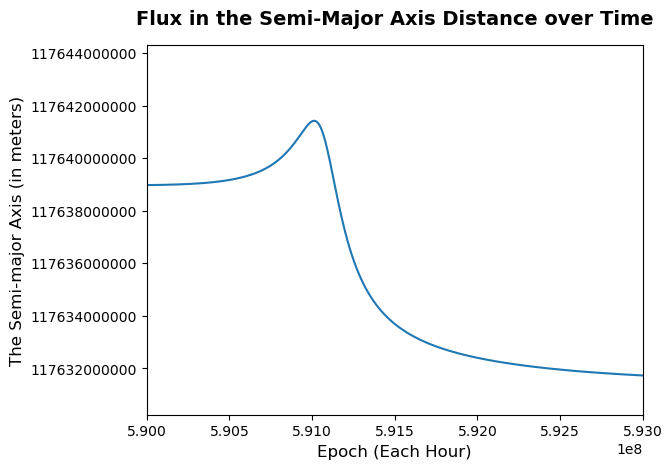

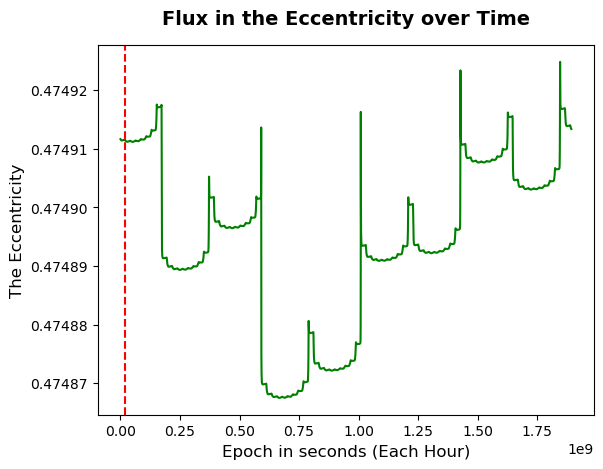

In [ ]:
# Extract and sort the data by epoch to ensure chronological order
epochs = sorted(kepler_history.keys())


# Check for how long the step occurs
prev_big_step_1 = 5.905e8
aft_big_step_1 = 5.93e8
time_step_hours_a_1 = (aft_big_step_1 - prev_big_step_1) / (3600)
time_step_days_a_1 = time_step_hours_a_1 / 24
print(time_step_hours_a_1)
print(time_step_days_a_1)

#plt.subplot(2, 2, 1)
plt.plot(epochs, a_kep_list)
plt.axvline(18838800.0, color='red', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('Flux in the Semi-Major Axis Distance over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch (Each Hour)', fontsize=12)
plt.ylabel('The Semi-major Axis (in meters)', fontsize=12)

plt.xlim(5.90e8, 5.93e8)

plt.show()

#plt.subplot(2, 2, 2)
plt.plot(epochs, e_kep_list, color='green')
plt.axvline(18838800.0, color='red', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('Flux in the Eccentricity over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch in seconds (Each Hour)', fontsize=12)
plt.ylabel('The Eccentricity', fontsize=12)

plt.show()

In [50]:
def current_position_function(time_fun, planet_name_fn, states_array_TU3_fn, body_system_fn):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    target_time_fn = time_fun

    # Find the index in the times array closest to target_time_1
    times_array = np.array(times)
    target_idx_fn = np.argmin(np.abs(times_array - target_time_fn))


    # ============================================================
    # SUN
    # ============================================================
    ax.scatter(0, 0, 0, s=100, label="Sun", color="orange")

    # ============================================================
    # TU3 ORBIT
    # ============================================================
    x_TU3_fn = states_array_TU3_fn[:, 1]
    y_TU3_fn = states_array_TU3_fn[:, 2]
    z_TU3_fn = states_array_TU3_fn[:, 3]

    ax.plot(
        x_TU3_fn,
        y_TU3_fn,
        z_TU3_fn,
        label="1998-TU3",
        linestyle="-."
    )

    # Plot TU3 at target time
    ax.scatter(
        x_TU3_fn[target_idx_fn],
        y_TU3_fn[target_idx_fn],
        z_TU3_fn[target_idx_fn],
        color="magenta",
        s=150,
        marker="*",
        label="TU3 at Target Time"
    )

    # ============================================================
    # Chosen Planet
    # ============================================================
    planet_states_fn = np.array([
        body_system_fn.get(planet_name_fn).ephemeris.cartesian_state(time)
        for time in times
    ])

    # Extract coordinates
    x_p_fn = planet_states_fn[:, 0]
    y_p_fn = planet_states_fn[:, 1]
    z_p_fn = planet_states_fn[:, 2]

    # Plot orbit
    ax.plot(
        x_p_fn,
        y_p_fn,
        z_p_fn,
        label=f"{planet_name_fn}"
    )

    # Plot Mercury at target time
    ax.scatter(
        x_p_fn[target_idx_fn],
        y_p_fn[target_idx_fn],
        z_p_fn[target_idx_fn],
        color="cyan",
        s=150,
        marker="o",
        label=f"{planet_name_fn} at Target Time"
    )

    # ============================================================
    # LABELS
    # ============================================================
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    # Around Jupiter Size
    ax.set_xlim(-5e10, 5e10)
    ax.set_ylim(-5e10, 5e10)
    ax.set_zlim(-5e10, 5e10)

    ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

    plt.tight_layout()
    plt.show()

    return fig, ax

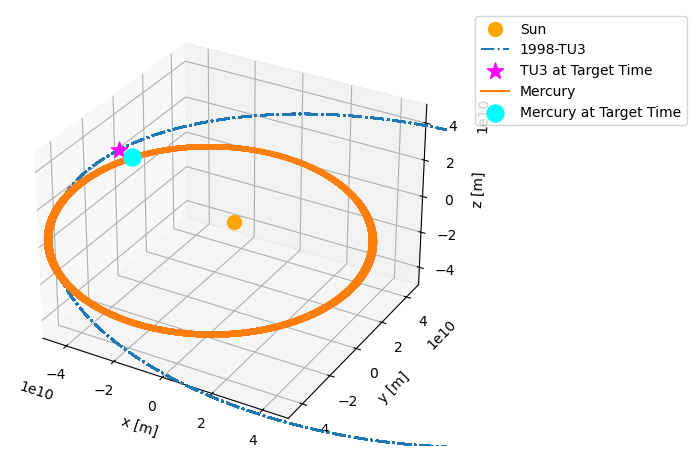

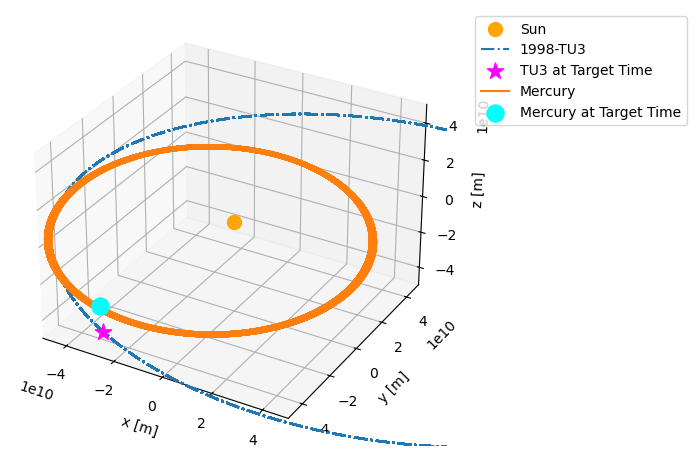

In [51]:
times_to_plot = [prev_big_step_1, aft_big_step_1]

for t in times_to_plot:
    current_position_function(
        time_fun = t,
        planet_name_fn = "Mercury",
        states_array_TU3_fn = states_array_TU3,
        body_system_fn = body_system
    )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Planet + 1998 TU3 for Maximum dw by Planet')

# ============================================================
# NEW: TARGET TIME SETTING
# ============================================================
# Insert the specific time here (in the same units as your 'times' array)
target_time_1 = prev_big_step_1

# Find the index in the times array closest to target_time_1
times_array = np.array(times)
target_idx_1 = np.argmin(np.abs(times_array - target_time_1))

print(f"Plotting positions for time: {times[target_idx_1]}")

# ============================================================
# SUN
# ============================================================
ax.scatter(0, 0, 0, s=100, label="Sun", color="orange")

# ============================================================
# TU3 ORBIT
# ============================================================
x_TU3 = states_array_TU3[:, 1]
y_TU3 = states_array_TU3[:, 2]
z_TU3 = states_array_TU3[:, 3]

ax.plot(
    x_TU3,
    y_TU3,
    z_TU3,
    label="1998-TU3",
    linestyle="-."
)

# Plot TU3 at target time
ax.scatter(
    x_TU3[target_idx_1],
    y_TU3[target_idx_1],
    z_TU3[target_idx_1],
    color="magenta",
    s=150,
    marker="*",
    label="TU3 at Target Time"
)

# ============================================================
# MERCURY
# ============================================================
planet_states = np.array([
    body_system.get("Mercury").ephemeris.cartesian_state(time)
    for time in times
])

# Extract coordinates
x_p = planet_states[:, 0]
y_p = planet_states[:, 1]
z_p = planet_states[:, 2]

# Plot orbit
ax.plot(
    x_p,
    y_p,
    z_p,
    label="Mercury"
)

# Plot Mercury at target time
ax.scatter(
    x_p[target_idx_1],
    y_p[target_idx_1],
    z_p[target_idx_1],
    color="cyan",
    s=150,
    marker="o",
    label="Mercury at Target Time"
)

# LABELS
# ============================================================
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# Around Jupiter Size
ax.set_xlim(-5e10, 5e10)
ax.set_ylim(-5e10, 5e10)
ax.set_zlim(-5e10, 5e10)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

In [7]:
epochs = []
omega_values_anglejump = []
true_anomaly_list = []
epoch_perihelion_list = []
index_list_peri = []

# To detect the perihelion in time
previous_nu = None

for i, (epoch, kep) in enumerate(kepler_history.items(), start=1):

    # Extract the true anomaly
    nu = kep[5]

    if previous_nu is not None:

        # Detect wraparound near perihelion
        # Cause there will be a jump from 2pi to 0
        if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
            epoch_perihelion_close = epoch
            epoch_perihelion_list.append(epoch_perihelion_close)
            index_list_peri.append(i)

            # epoch_days = epoch / (3600*24)
            # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

    previous_nu = nu

    # Extract the perihelion precession as well

    omega_test = kep[3]
    epochs.append(epoch)

    omega_values_anglejump.append(omega_test)

    

# Unwrap the angles :)
# Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
omega_values = np.unwrap(omega_values_anglejump)

print(epoch_perihelion_list)
print(index_list_peri)


# # The indicies below were inserted manually (I read off the printed list below)
# # The perihelion precession during the first year
# first_peri = perihelion_precess = np.degrees(omega_values[11354] -  omega_values[5234])
# # The perihelion precession after 15 years
# peri_precess_15_years = np.degrees(omega_values[-1] - omega_values[5234])

peri_precession_per_orbit_list = []

for i in index_list_peri:
    peri_deg = np.degrees(omega_values[i+1] -  omega_values[i])
    peri_precession_per_orbit_list.append(peri_deg)

# print(first_peri)
# print(peri_precess_15_years)
print(peri_precession_per_orbit_list)


[18817200.0, 40824000.0, 62830800.0, 84837600.0, 106844400.0, 128851200.0, 150858000.0, 172868400.0, 194871600.0, 216878400.0, 238885200.0, 260888400.0, 282895200.0, 304902000.0, 326905200.0, 348912000.0, 370918800.0, 392925600.0, 414928800.0, 436935600.0, 458942400.0, 480949200.0, 502956000.0, 524962800.0, 546966000.0, 568972800.0, 590979600.0, 612982800.0, 634989600.0, 656992800.0, 678996000.0, 701002800.0, 723006000.0, 745009200.0, 767012400.0, 789019200.0, 811022400.0, 833029200.0, 855032400.0, 877039200.0, 899042400.0, 921045600.0, 943052400.0, 965055600.0, 987062400.0, 1009065600.0, 1031072400.0, 1053079200.0, 1075082400.0, 1097089200.0, 1119096000.0, 1141099200.0, 1163106000.0, 1185112800.0, 1207116000.0, 1229122800.0, 1251129600.0, 1273136400.0, 1295143200.0, 1317146400.0, 1339153200.0, 1361160000.0, 1383166800.0, 1405170000.0, 1427176800.0, 1449183600.0, 1471190400.0, 1493197200.0, 1515204000.0, 1537210800.0, 1559217600.0, 1581224400.0, 1603231200.0, 1625238000.0, 1647244800.0

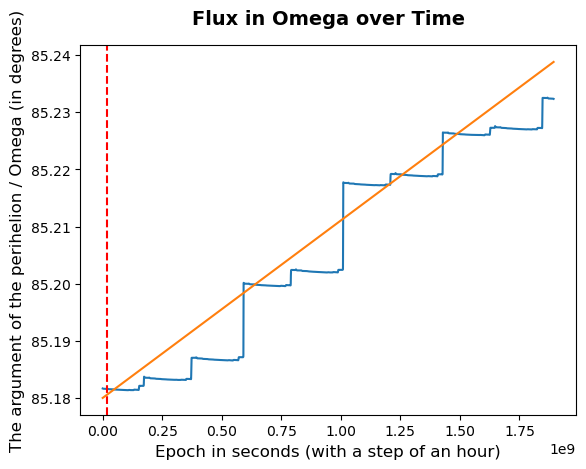

In [8]:
plt.plot(epochs, np.degrees(omega_values))
plt.axvline(18838800.0, color='red', linestyle='--', linewidth=1.5)

# Check a linear relation going through the oscillations
lin_slope = np.polyfit(epochs,np.degrees(omega_values),1)[0]
y_test = 85.18 + lin_slope * np.array(epochs)
plt.plot(epochs, y_test)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('Flux in Omega over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch in seconds (with a step of an hour)', fontsize=12)
plt.ylabel('The argument of the perihelion / Omega (in degrees)', fontsize=12)

# plt.ylim(85, 85.5)

plt.show()

In [9]:
# Finding the slope

# Arcseconds
omega_arcseconds = np.degrees(omega_values) * 3600

# The epochs are currently in seconds, when they should be per century
epochs_centuery = np.array(epochs) / (100 * 365 * 24 * 3600)

print(np.polyfit(epochs,np.degrees(omega_values),1)[0])
print(f"The perihelion precession: {np.polyfit(epochs_centuery,omega_arcseconds,1)[0]} arcesconds/ century")

3.105738353667952e-11
The perihelion precession: 352.59323299822734 arcesconds/ century


In [10]:
# First, calculate the omega values and the difference in them
omega_deg = np.degrees(omega_values)
delta_omega = np.diff(omega_deg)
epochs_array = np.array(epochs)

# 2. Calculate the standard deviation of the changes
std_dev = np.std(delta_omega)

# 3. Use a much higher threshold (e.g., 10 to 20 times the Standard Deviation)
# This ignores the "noise" of slow precession and catches the "shocks"
threshold = 40 * std_dev 

# 4. Find the indices
step_indices = np.where(np.abs(delta_omega) > threshold)[0]
step_epochs = epochs_array[step_indices]

print(f"Detected {len(step_epochs)} massive steps at {step_epochs}.")

Detected 107 massive steps at [5.9098680e+08 5.9099040e+08 5.9099400e+08 5.9099760e+08 5.9100120e+08
 5.9100480e+08 5.9100840e+08 5.9101200e+08 5.9101560e+08 5.9101920e+08
 5.9102280e+08 5.9102640e+08 5.9103000e+08 5.9103360e+08 5.9103720e+08
 5.9104080e+08 5.9104440e+08 5.9104800e+08 5.9105160e+08 5.9105520e+08
 5.9105880e+08 5.9106240e+08 5.9106600e+08 5.9106960e+08 5.9107320e+08
 5.9107680e+08 5.9108040e+08 5.9108400e+08 5.9108760e+08 5.9109120e+08
 5.9109480e+08 5.9109840e+08 5.9110200e+08 5.9110560e+08 5.9110920e+08
 5.9111280e+08 5.9111640e+08 5.9112000e+08 5.9112360e+08 5.9112720e+08
 5.9113080e+08 5.9113440e+08 5.9113800e+08 5.9114160e+08 5.9114520e+08
 5.9114880e+08 5.9115240e+08 5.9115600e+08 5.9115960e+08 1.0091736e+09
 1.0091772e+09 1.0091808e+09 1.0091844e+09 1.0091880e+09 1.0091916e+09
 1.0091952e+09 1.0091988e+09 1.0092024e+09 1.0092060e+09 1.0092096e+09
 1.0092132e+09 1.0092168e+09 1.0092204e+09 1.0092240e+09 1.0092276e+09
 1.0092312e+09 1.0092348e+09 1.0092384e+09 1.00

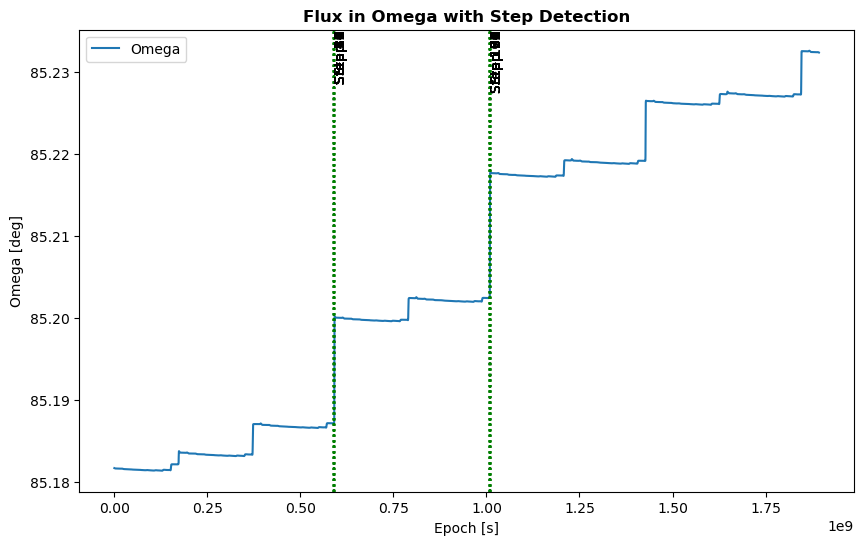

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, omega_deg, label='Omega')

# Mark each detected step
for i, s_epoch in enumerate(step_epochs):
    plt.axvline(s_epoch, color='green', linestyle=':', alpha=0.6)
    # Optional: label them with their index or time
    plt.text(s_epoch, plt.ylim()[1], f'Step {i+1}', rotation=90, verticalalignment='top')

# Formatting
plt.title('Flux in Omega with Step Detection', fontweight='bold')
plt.xlabel('Epoch [s]')
plt.ylabel('Omega [deg]')
plt.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.legend()
plt.show()

Plotting positions for time: 590997600.0


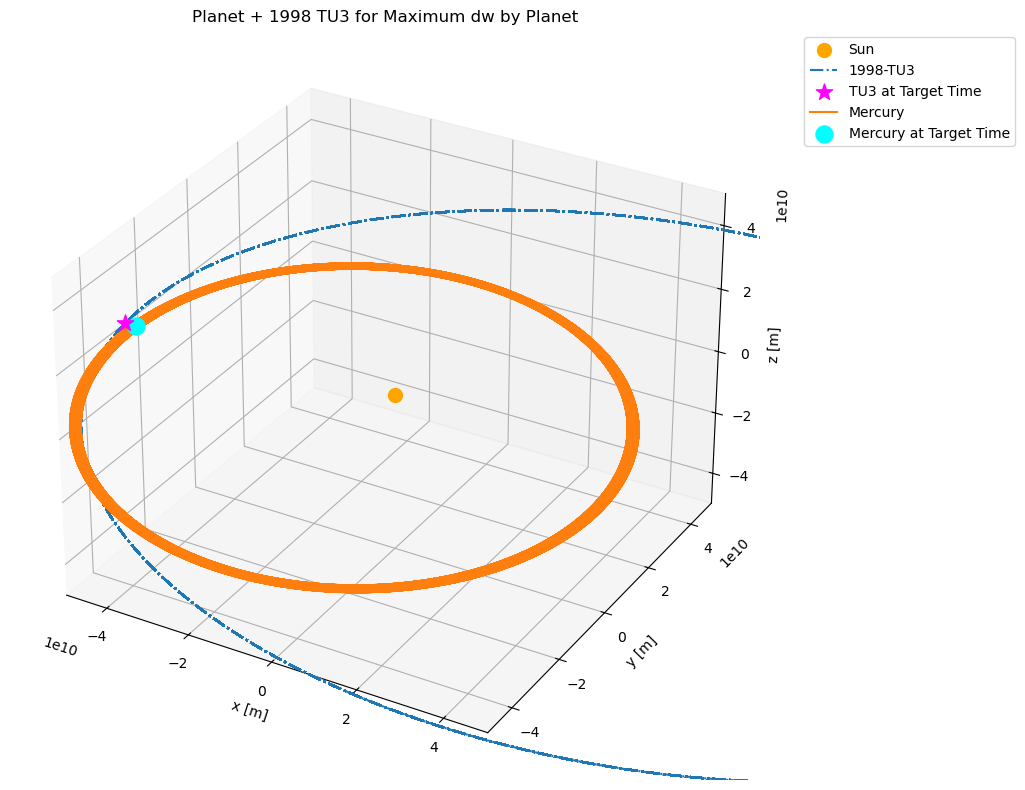

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Planet + 1998 TU3 for Maximum dw by Planet')

# ============================================================
# NEW: TARGET TIME SETTING
# ============================================================
# Insert the specific time here (in the same units as your 'times' array)
target_time_1 = 5.909976e+08

# Find the index in the times array closest to target_time_1
times_array = np.array(times)
target_idx_1 = np.argmin(np.abs(times_array - target_time_1))

print(f"Plotting positions for time: {times[target_idx_1]}")

# ============================================================
# SUN
# ============================================================
ax.scatter(0, 0, 0, s=100, label="Sun", color="orange")

# ============================================================
# TU3 ORBIT
# ============================================================
x_TU3 = states_array_TU3[:, 1]
y_TU3 = states_array_TU3[:, 2]
z_TU3 = states_array_TU3[:, 3]

ax.plot(
    x_TU3,
    y_TU3,
    z_TU3,
    label="1998-TU3",
    linestyle="-."
)

# Plot TU3 at target time
ax.scatter(
    x_TU3[target_idx_1],
    y_TU3[target_idx_1],
    z_TU3[target_idx_1],
    color="magenta",
    s=150,
    marker="*",
    label="TU3 at Target Time"
)

# ============================================================
# MERCURY
# ============================================================
planet_states = np.array([
    body_system.get("Mercury").ephemeris.cartesian_state(time)
    for time in times
])

# Extract coordinates
x_p = planet_states[:, 0]
y_p = planet_states[:, 1]
z_p = planet_states[:, 2]

# Plot orbit
ax.plot(
    x_p,
    y_p,
    z_p,
    label="Mercury"
)

# Plot Mercury at target time
ax.scatter(
    x_p[target_idx_1],
    y_p[target_idx_1],
    z_p[target_idx_1],
    color="cyan",
    s=150,
    marker="o",
    label="Mercury at Target Time"
)

# ============================================================
# LABELS
# ============================================================
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# Around Jupiter Size
ax.set_xlim(-5e10, 5e10)
ax.set_ylim(-5e10, 5e10)
ax.set_zlim(-5e10, 5e10)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

Plotting positions for time: 1009180800.0


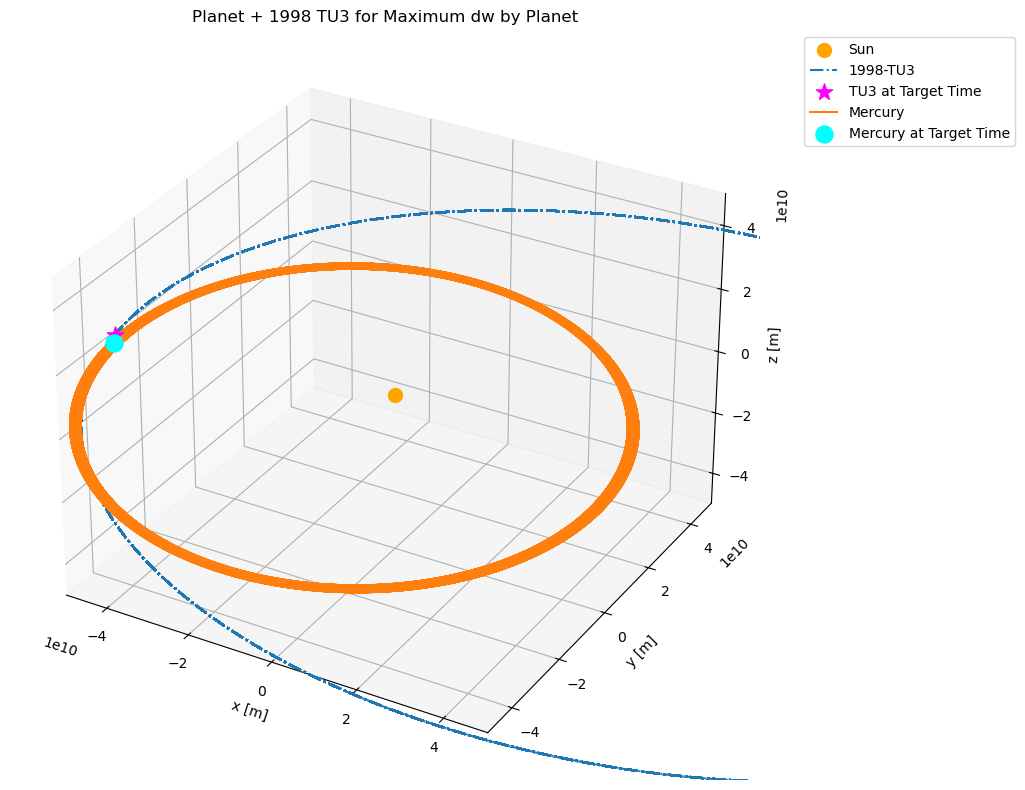

In [13]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Planet + 1998 TU3 for Maximum dw by Planet')

# ============================================================
# NEW: TARGET TIME SETTING
# ============================================================
# Insert the specific time here (in the same units as your 'times' array)
target_time_2 = 1.0091808e+09

# Find the index in the times array closest to target_time_2
times_array = np.array(times)
target_idx_2 = np.argmin(np.abs(times_array - target_time_2))

print(f"Plotting positions for time: {times[target_idx_2]}")

# ============================================================
# SUN
# ============================================================
ax.scatter(0, 0, 0, s=100, label="Sun", color="orange")

# ============================================================
# TU3 ORBIT
# ============================================================
x_TU3 = states_array_TU3[:, 1]
y_TU3 = states_array_TU3[:, 2]
z_TU3 = states_array_TU3[:, 3]

ax.plot(
    x_TU3,
    y_TU3,
    z_TU3,
    label="1998-TU3",
    linestyle="-."
)

# Plot TU3 at target time
ax.scatter(
    x_TU3[target_idx_2],
    y_TU3[target_idx_2],
    z_TU3[target_idx_2],
    color="magenta",
    s=150,
    marker="*",
    label="TU3 at Target Time"
)

# ============================================================
# MERCURY
# ============================================================
planet_states = np.array([
    body_system.get("Mercury").ephemeris.cartesian_state(time)
    for time in times
])

# Extract coordinates
x_p = planet_states[:, 0]
y_p = planet_states[:, 1]
z_p = planet_states[:, 2]

# Plot orbit
ax.plot(
    x_p,
    y_p,
    z_p,
    label="Mercury"
)

# Plot Mercury at target time
ax.scatter(
    x_p[target_idx_2],
    y_p[target_idx_2],
    z_p[target_idx_2],
    color="cyan",
    s=150,
    marker="o",
    label="Mercury at Target Time"
)

# ============================================================
# LABELS
# ============================================================
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# Around Jupiter Size
ax.set_xlim(-5e10, 5e10)
ax.set_ylim(-5e10, 5e10)
ax.set_zlim(-5e10, 5e10)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

525961
Index for the smallest distance: 280344
Time of the smallest distance: 1009238400.0
Minimum distance between the two bodies: 2022378784.9211674 m


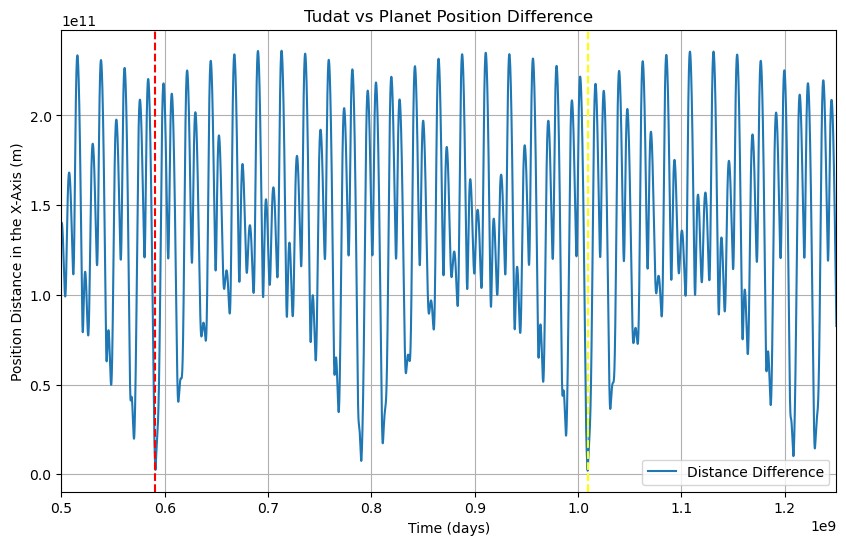

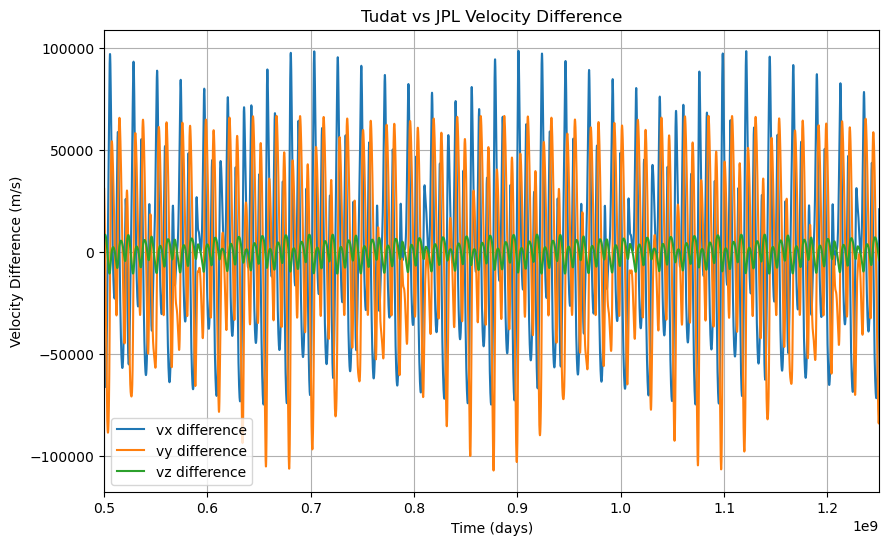

In [25]:
# Examine how far apart the simulated values of TU3 are from the Planet at designated times

# All the states made by Tudat are put into statues_TU3
print(len(states_TU3))

# Extract columns
t_TU3  = states_array_TU3[:, 0]

# I have already extracted the positions as x_TU3, x_p etc.

vx_TU3 = states_array_TU3[:, 4]
vy_TU3 = states_array_TU3[:, 5]
vz_TU3 = states_array_TU3[:, 6]

vx_p = planet_states[:,3]
vy_p = planet_states[:,4]
vz_p = planet_states[:,5]


# Then compare the values from Tudat and JPL Horizon
 
x_comp = x_TU3 - x_p 
y_comp = y_TU3 - y_p
z_comp = z_TU3 - z_p

vx_comp = vx_TU3 - vx_p
vy_comp = vy_TU3 - vy_p
vz_comp = vz_TU3 - vz_p


# Printing the difference in distance from each other

diff_distance = np.sqrt(
    (x_TU3 - x_p)**2 +
    (y_TU3 - y_p)**2 +
    (z_TU3 - z_p)**2
)

idx_smallest_distance = np.argmin(diff_distance)

smallest_distance = diff_distance[idx_smallest_distance]

print(f"Index for the smallest distance: {idx_smallest_distance}")
print(f"Time of the smallest distance: {t_TU3[idx_smallest_distance]}")
print(f"Minimum distance between the two bodies: {smallest_distance} m")

t_TU3_days = t_TU3 # / (24*3600)  # From seconds to days
perihelion_time = 18838800.0 # / (24*3600)    # This time is found in the Jupyter Notebook TU3_orbit_precession_2.ipynb

# =========================
# POSITION DIFFERENCES
# =========================

plt.figure(figsize=(10, 6))

# plt.plot(t_TU3_days, x_comp, label='x difference')
# plt.plot(t_TU3_days, y_comp, label='y difference')
# plt.plot(t_TU3_days, z_comp, label='z difference')
plt.plot(t_TU3_days, diff_distance, label='Distance Difference')
# plt.plot(t_TU3_days, x_TU3, label='z difference', color='red')        # Tudat x-position
# plt.plot(t_TU3_days, x_JPL, label='z difference', color='yellow')     # JPL x-position
# plt.axvline(perihelion_time, label='Perihelion passing', color='red', linestyle='--', linewidth=1.5)      # Perihelion time

# The target times (when the major jumps in the Keplerian elements occurs)
plt.axvline(target_time_1, color='red', linestyle='--', linewidth=1.5)
plt.axvline(target_time_2, color='yellow', linestyle='--', linewidth=1.5)

plt.xlabel('Time (days)')
plt.ylabel('Position Distance in the X-Axis (m)')
plt.title('Tudat vs Planet Position Difference')

plt.xlim(0.5e9, 1.25e9)

plt.legend()
plt.grid(True)

plt.show()


# =========================
# VELOCITY DIFFERENCES
# =========================

plt.figure(figsize=(10, 6))

plt.plot(t_TU3_days, vx_comp, label='vx difference')
plt.plot(t_TU3_days, vy_comp, label='vy difference')
plt.plot(t_TU3_days, vz_comp, label='vz difference')

plt.xlabel('Time (days)')
plt.ylabel('Velocity Difference (m/s)')
plt.title('Tudat vs JPL Velocity Difference')

plt.xlim(0.5e9, 1.25e9)

plt.legend()
plt.grid(True)

plt.show()